# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load Cleaned Data

In [4]:
sales = pd.read_csv("../datasets/processed datasets/clean_sales.csv")
products = pd.read_csv("../datasets/processed datasets/clean_products.csv")
stores = pd.read_csv("../datasets/processed datasets/clean_stores.csv")
shelf = pd.read_csv("../datasets/processed datasets/clean_shelf_audit.csv")

# Total Revenue

In [5]:
total_revenue = sales["sales_amount"].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 142186709.35


# Revenue by Category

In [6]:
category_sales = (
    sales.merge(products,on="sku_id")
         .groupby("category")["sales_amount"]
         .sum()
         .sort_values(ascending=False)
)

category_sales

category
Snacks           28240123.93
Household        26184655.12
Personal Care    24746983.28
Dairy            21947100.35
Beverages        21371808.63
Bakery           19696038.04
Name: sales_amount, dtype: float64

# Plot Revenue by Category

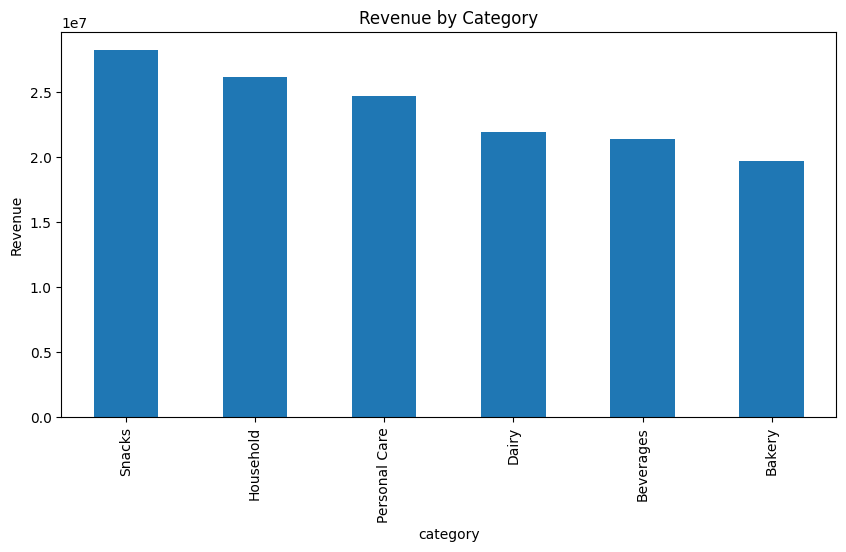

In [7]:
plt.figure(figsize=(10,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Category")

plt.ylabel("Revenue")

plt.show()

# Revenue by Region

In [8]:
region_sales = (
    sales.merge(stores,on="store_id")
         .groupby("region")["sales_amount"]
         .sum()
         .sort_values(ascending=False)
)

region_sales

region
West     47939852.80
North    39875047.20
South    34370253.15
East     20001556.20
Name: sales_amount, dtype: float64

# Plot Revenue by Region

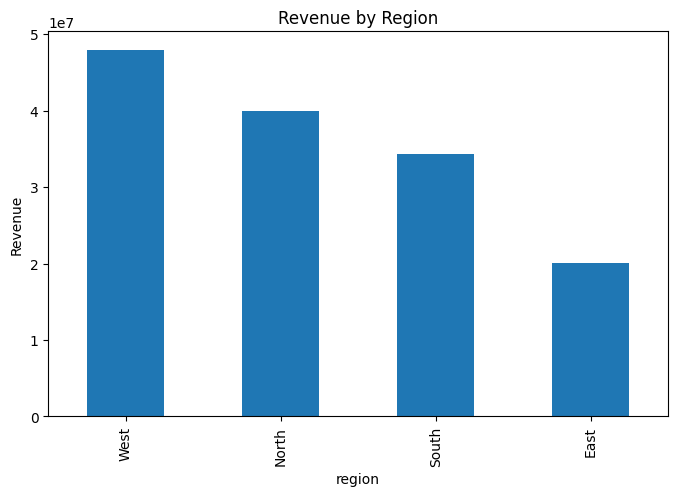

In [9]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")

plt.ylabel("Revenue")

plt.show()

# Top 10 Stores

In [10]:
top_stores = (
    sales.merge(stores,on="store_id")
         .groupby("store_name")["sales_amount"]
         .sum()
         .sort_values(ascending=False)
         .head(10)
)

top_stores

store_name
RetailMart Mumbai-9        3000719.70
RetailMart Chennai-27      2991399.33
RetailMart Jaipur-31       2975427.17
RetailMart Kolkata-3       2970321.26
RetailMart Jaipur-47       2957877.63
RetailMart Lucknow-32      2950962.78
RetailMart Hyderabad-30    2931790.96
RetailMart Chennai-43      2931190.70
RetailMart Hyderabad-4     2922506.08
RetailMart Chennai-48      2917260.22
Name: sales_amount, dtype: float64

# Plot Top Stores

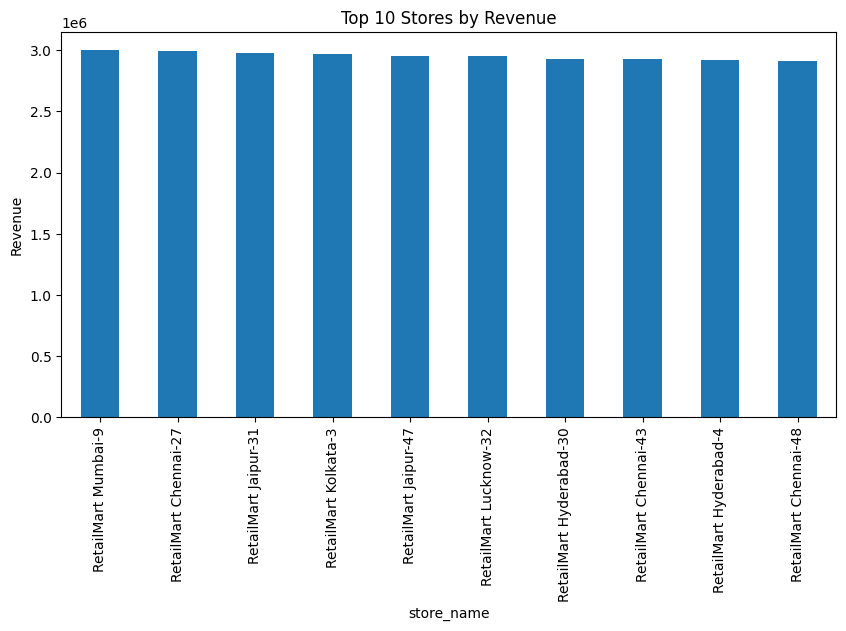

In [11]:
plt.figure(figsize=(10,5))

top_stores.plot(kind="bar")

plt.title("Top 10 Stores by Revenue")

plt.ylabel("Revenue")

plt.show()

# Top Products

In [12]:
top_products = (
    sales.merge(products,on="sku_id")
         .groupby("product_name")["sales_amount"]
         .sum()
         .sort_values(ascending=False)
         .head(10)
)

top_products

product_name
Pears Product 214           614928.40
Fanta Product 330           608180.32
Dettol Product 230          597117.60
Sprite Product 429          576843.48
Nestle Product 360          559711.90
Lizol Product 384           559508.38
Harpic Product 20           557662.25
Modern Product 464          556782.48
Mother Dairy Product 131    553208.88
Pringles Product 245        552239.06
Name: sales_amount, dtype: float64

# Product Revenue Plot

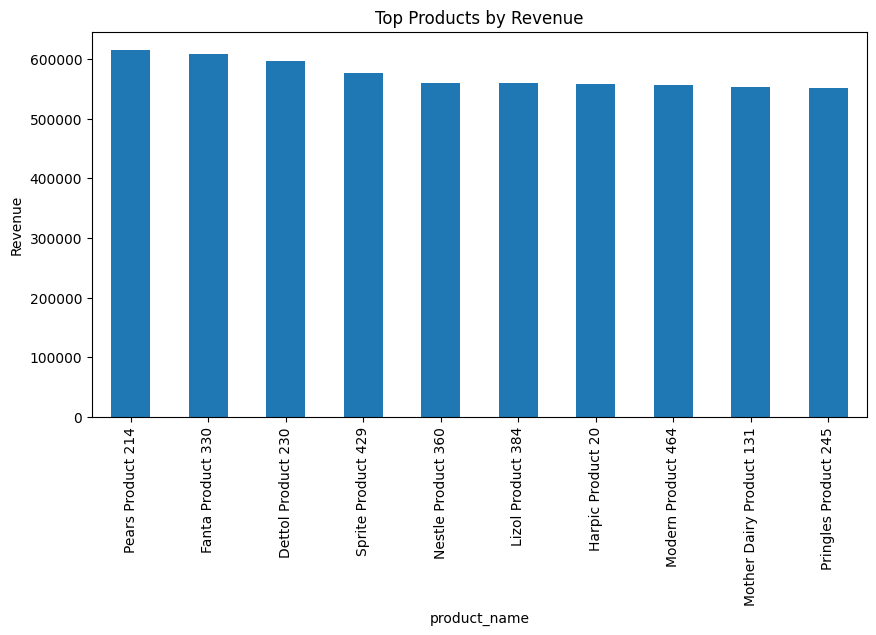

In [13]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top Products by Revenue")

plt.ylabel("Revenue")

plt.show()

# Average Visibility Score

In [14]:
avg_visibility = shelf["visibility_score"].mean()

print("Average Visibility Score:",round(avg_visibility,2))

Average Visibility Score: 57.26


# Shelf Compliance Analysis

In [15]:
shelf["shelf_compliance"].value_counts()

shelf_compliance
Compliant        15431
Non-Compliant     9569
Name: count, dtype: int64

# Audit Issue Analysis

In [16]:
shelf["audit_issue"].value_counts()

audit_issue
Unknown              15431
Low Visibility        6436
Stock Out             2291
Misplaced Product      842
Name: count, dtype: int64

# Revenue Leakage

In [17]:
revenue_leakage = total_revenue * 0.05

print("Estimated Revenue Leakage:", revenue_leakage)

Estimated Revenue Leakage: 7109335.467500001


# Business Insights

1. Identify highest revenue generating categories.
2. Detect underperforming stores.
3. Measure shelf visibility performance.
4. Analyze audit issues.
5. Estimate revenue leakage.
6. Support inventory planning decisions.
7. Improve shelf compliance across stores.

#  Export Reports

In [18]:
top_stores.to_csv(
    "../reports/top_stores.csv",
    index=False
)

category_sales.to_csv(
    "../reports/category_revenue.csv",
    index=False
)

top_products.to_csv(
    "../reports/problematic_products.csv",
    index=False
)